   model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   GT86  2016  16000       Manual    24089   Petrol  265  36.2         2.0
1   GT86  2017  15995       Manual    18615   Petrol  145  36.2         2.0
2   GT86  2015  13998       Manual    27469   Petrol  265  36.2         2.0
3   GT86  2017  18998       Manual    14736   Petrol  150  36.2         2.0
4   GT86  2017  17498       Manual    36284   Petrol  145  36.2         2.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   eng

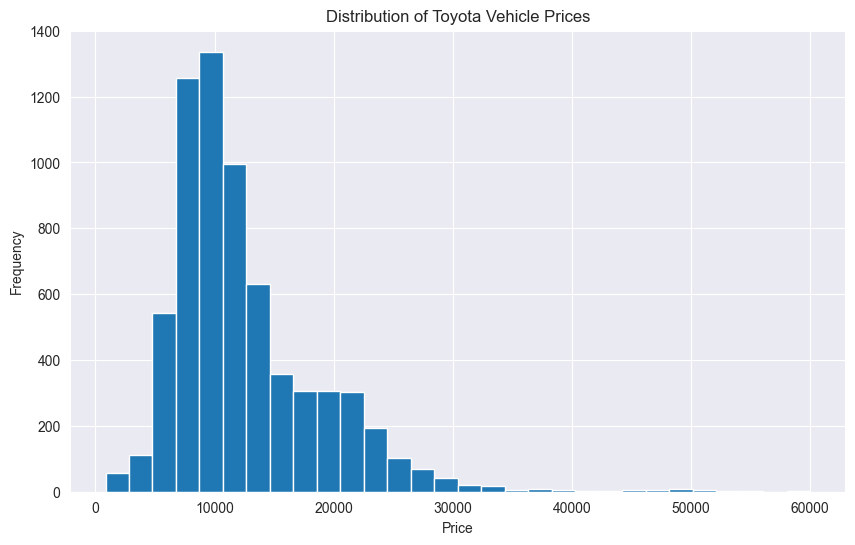

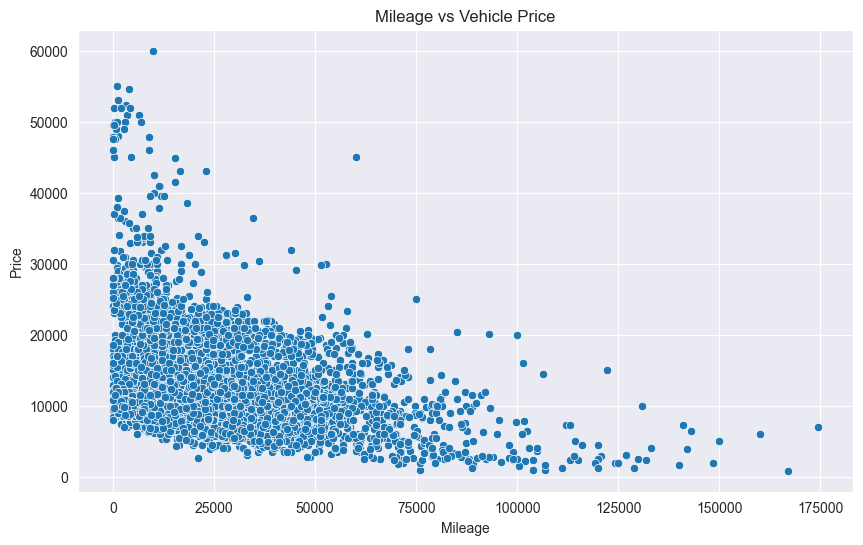

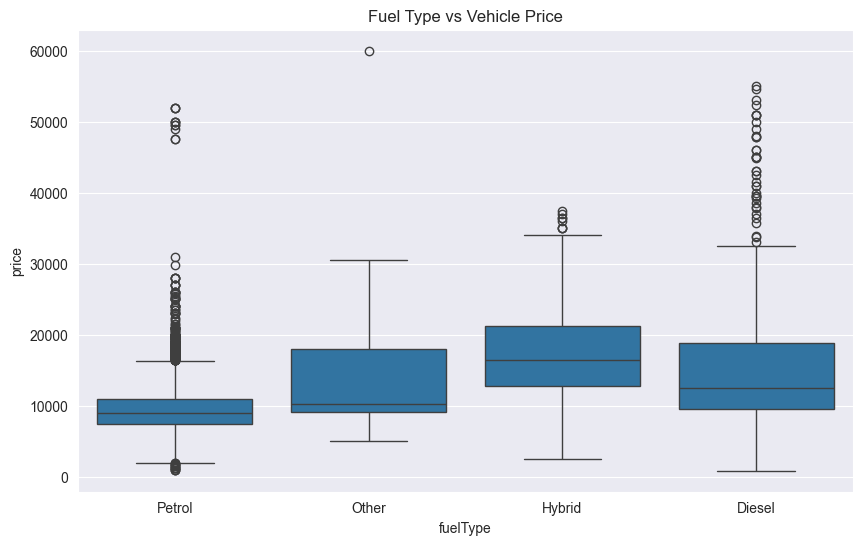

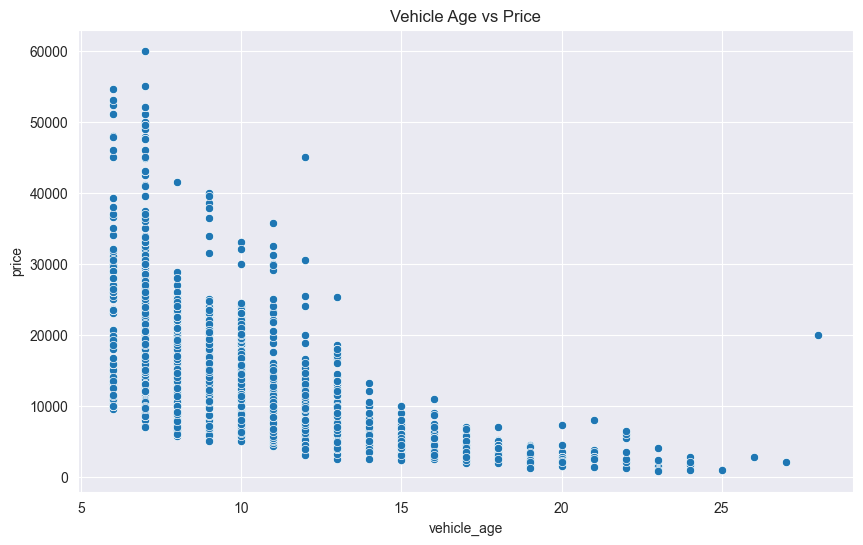

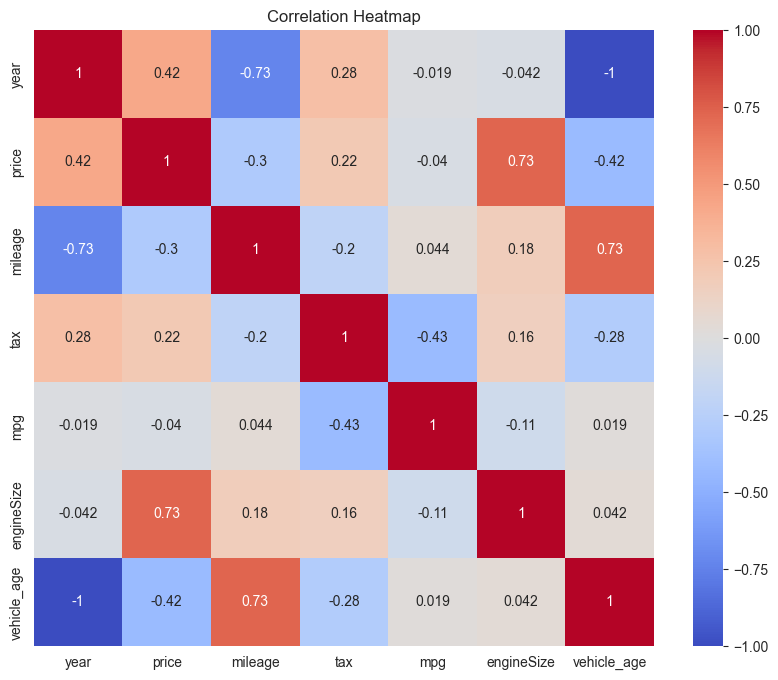


Model Results
Mean Absolute Error: 1101.89
R² Score: 0.932


In [1]:
# Toyota Used Car Market Analysis - Week 10
# Megan Pokal - DSC 680

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset
data = pd.read_csv("toyota.csv")

# View first records
print(data.head())

# Dataset information
print(data.info())

# Summary statistics
print(data.describe())

# Data Cleaning

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove any duplicates
data.drop_duplicates(inplace=True)

# Create vehicle age variable

current_year = 2026
data["vehicle_age"] = current_year - data["year"]

print(data.head())


# Visualization 1: Distribution of Prices

plt.figure(figsize=(10,6))
plt.hist(data["price"], bins=30)

plt.title("Distribution of Toyota Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

# Visualization 2: Mileage vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="mileage",
    y="price",
    data=data
)

plt.title("Mileage vs Vehicle Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()

# Visualization 3: Fuel Type vs Price

plt.figure(figsize=(10,6))

sns.boxplot(
    x="fuelType",
    y="price",
    data=data
)

plt.title("Fuel Type vs Vehicle Price")

plt.show()

# Visualization 4: Vehicle Age vs Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="vehicle_age",
    y="price",
    data=data
)

plt.title("Vehicle Age vs Price")

plt.show()

# Visualization 5: Correlation Heatmap

numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Predictive Model: Linear Regression

# Convert categorical variables
encoded_data = pd.get_dummies(
    data,
    columns=["fuelType","transmission","model"],
    drop_first=True
)

# Define predictors and target
X = encoded_data.drop(
    ["price"],
    axis=1
)

y = encoded_data["price"]

# Split train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# Predictions
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

# Print
print("\nModel Results")
print("Mean Absolute Error:", round(mae,2))
print("R² Score:", round(r2,3))